In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [4]:
x,y = make_regression(n_samples = 100, n_features = 1, n_informative = 1, n_targets = 1, noise = 20, random_state =13)

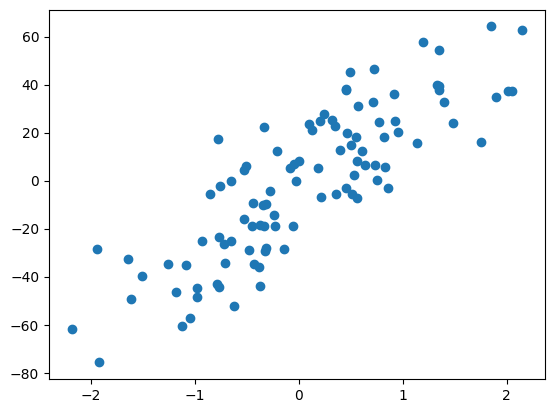

In [5]:
plt.scatter(x,y)

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(x_train,y_train)

LinearRegression()

In [11]:
y_pred = lr.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [28]:
class GDRegressor:

    def __init__(self,learning_rate,epochs):

        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,x,y):

        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m * x.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m * x.ravel() - self.b)* x.ravel()) 

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)

    def predict(self,x):
        return self.m * x + self.b

In [29]:
gd = GDRegressor(0.001,50)

In [30]:
gd.fit(x_train,y_train)

28.159367347119066 -2.3004574196824854


In [32]:
y_pred = gd.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6343842836315579

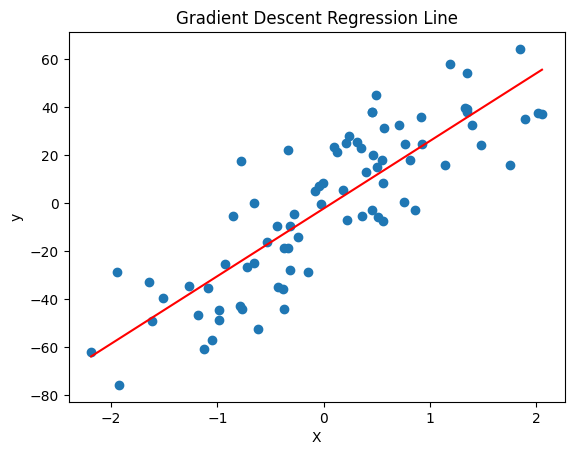

In [34]:
# Scatter plot (actual data)
plt.scatter(x_train, y_train)
# Create a smooth line
x_line = np.linspace(x_train.min(), x_train.max(), 100).reshape(-1,1)
y_line = gd.predict(x_line)
# Plot regression line
plt.plot(x_line, y_line, color = 'red')

plt.title("Gradient Descent Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

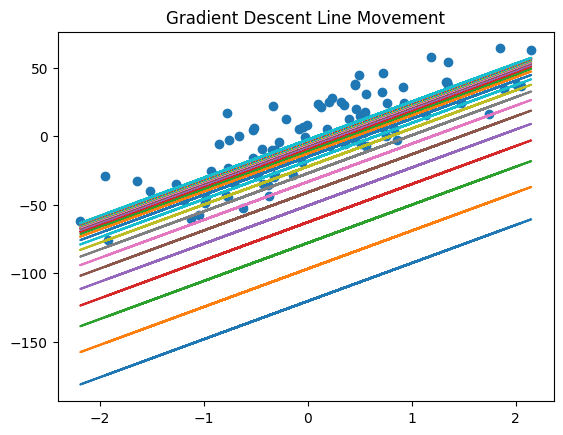

In [47]:
import matplotlib.pyplot as plt

b = -150
m = 27.82
lr = 0.001

epochs = 30

plt.scatter(x, y)  # actual data

for i in range(epochs):
    slope = 0

    for j in range(x.shape[0]):
        slope = slope - 2 * (y[j] - (m * x[j]) - b)

    b = b - (lr * slope)

    y_pred = m * x + b
    plt.plot(x, y_pred)  # line at each step

plt.title("Gradient Descent Line Movement")
plt.show()

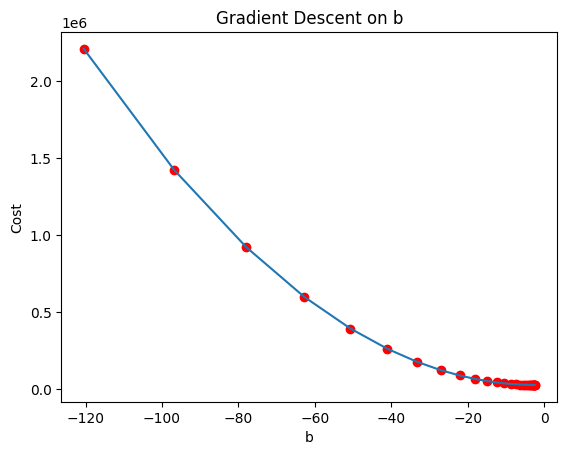

In [44]:
b = -150
m = 27.82
lr = 0.001

all_b = []
all_cost = []

epochs = 30

for i in range(epochs):
    slope = 0
    cost = 0

    for j in range(x.shape[0]):
        error = y[j] - (m * x[j]) - b
        slope += -2 * error
        cost += error ** 2

    b = b - (lr * slope)

    all_b.append(b)
    all_cost.append(cost)

# Plot curve + points
plt.plot(all_b, all_cost)        # smooth-ish curve
plt.scatter(all_b, all_cost,color='red')    # red descent steps

plt.xlabel("b")
plt.ylabel("Cost")
plt.title("Gradient Descent on b")
plt.show()